<a href="https://colab.research.google.com/github/np03cs4a240306-blip/Saurav-Sapkota/blob/main/2509463_SAURAVSAPKOTA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
print("=" * 30)
print("IMPORTS & DATA LOADING")
print("=" * 30)



IMPORTS & DATA LOADING


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv(
    "/content/Human_Development_Index_Dataset (1).csv",
    encoding="latin1"
)



In [ ]:
print("=" * 80)
print("PROBLEM 1A – SINGLE YEAR HDI (2022)")
print("=" * 80)

PROBLEM 1A – SINGLE YEAR HDI (2022)


In [3]:
#Task 1: Extract Latest Year
df['year'].unique()


array([1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000,
       2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011,
       2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022])

In [4]:
hdi_2022_df = df[df['year'] == 2022].copy()


In [5]:
#Task 2: Data Exploration
hdi_2022_df.head(10)


,Unnamed: 0,iso3,country,year,hdi,life_expectancy,pop_millions,hdi_f,hdi_m,life_expec_f,...,gender_development,gender_inequality,secondary_education_f_%,secondary_education_m_%,seats_in_parliament_f_%,seats_in_parliament_m_%,labour_participation_f_%,labour_participation_m_%,co2_emission_tons,mat_footprint_percap_tons
32,33,AFG,Afghanistan,2022,0.462,62.879,41.128771,0.332443,0.534145,66.213,...,0.622,0.665,7.042050,24.077040,27.215190,72.784810,23.33,77.09,0.306318,1.1809
65,66,ALB,Albania,2022,0.789,76.833,2.842321,0.780277,0.798432,79.472,...,0.977,0.116,82.249185,86.476634,35.714286,64.285714,56.08,69.91,1.717758,11.7367
98,99,DZA,Algeria,2022,0.745,77.129,44.903225,0.681844,0.773800,78.457,...,0.881,0.460,42.910456,46.815170,7.005254,92.994746,17.57,65.53,4.079540,8.7199
131,132,AND,Andorra,2022,0.884,83.552,0.079824,NaN,NaN,85.838,...,NaN,NaN,81.718277,84.599998,46.428571,53.571429,NaN,NaN,4.593593,NaN
164,165,AGO,Angola,2022,0.591,61.929,35.588987,0.560890,0.619680,64.541,...,0.905,0.520,21.339865,37.411946,33.636364,66.363636,74.73,78.16,0.507359,3.6568
197,198,ATG,Antigua and Barbuda,2022,0.826,79.236,0.093763,NaN,NaN,81.645,...,NaN,NaN,NaN,NaN,31.428571,68.571429,NaN,NaN,6.401056,NaN
230,231,ARG,Argentina,2022,0.849,76.064,45.510318,0.841405,0.845473,79.277,...,0.995,0.292,73.591541,71.648085,44.376900,55.623100,52.08,71.74,4.190779,14.4512
263,264,ARM,Armenia,2022,0.786,73.372,2.780469,0.795110,0.774942,78.447,...,1.026,0.198,96.001381,97.050957,35.514019,64.485981,62.80,71.84,2.531088,7.3553
296,297,AUS,Australia,2022,0.946,83.579,26.177414,0.934602,0.955941,85.453,...,0.978,0.063,94.580063,94.430069,44.493392,55.506608,62.31,71.13,14.914763,26.9245
329,330,AUT,Austria,2022,0.926,82.412,8.939617,0.911592,0.937756,84.600,...,0.972,0.048,100.000000,100.000000,40.983607,59.016393,56.55,66.69,7.399461,27.9621


In [7]:
hdi_2022_df.shape


(206, 30)

In [6]:
hdi_2022_df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 206 entries, 32 to 6797
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Unnamed: 0                 206 non-null    int64  
 1   iso3                       206 non-null    object 
 2   country                    206 non-null    object 
 3   year                       206 non-null    int64  
 4   hdi                        204 non-null    float64
 5   life_expectancy            206 non-null    float64
 6   pop_millions               206 non-null    float64
 7   hdi_f                      193 non-null    float64
 8   hdi_m                      193 non-null    float64
 9   life_expec_f               206 non-null    float64
 10  life_expec_m               206 non-null    float64
 11  expec_yr_school            205 non-null    float64
 12  expec_yr_school_f          205 non-null    float64
 13  expec_yr_school_m          205 non-null    float64
 1

In [8]:
#Task 3: Missing Values & Cleaning
hdi_2022_df.isnull().sum()


,0
Unnamed: 0,0
iso3,0
country,0
year,0
hdi,2
life_expectancy,0
pop_millions,0
hdi_f,13
hdi_m,13
life_expec_f,0


In [9]:
# Remove duplicates
hdi_2022_df.drop_duplicates(inplace=True)


In [10]:

hdi_2022_df.columns = hdi_2022_df.columns.str.lower().str.strip()

cols_to_convert = [col for col in hdi_2022_df.columns if 'hdi' in col or 'gross' in col or 'expectancy' in col]

print(f"Columns found for conversion: {cols_to_convert}")

for col in cols_to_convert:
    hdi_2022_df[col] = pd.to_numeric(hdi_2022_df[col], errors='coerce')

Columns found for conversion: ['hdi', 'life_expectancy', 'hdi_f', 'hdi_m', 'gross_inc_percap', 'gross_inc_percap_f', 'gross_inc_percap_m']


In [11]:
#Task 4: Basic Statistics
hdi_2022_df['hdi'].mean()


np.float64(0.7228872549019609)

In [12]:
hdi_2022_df['hdi'].median()


0.7395

In [13]:
hdi_2022_df['hdi'].std()


0.15302880386427825

In [14]:
hdi_2022_df.loc[hdi_2022_df['hdi'].idxmax(), ['country', 'hdi']]


,5609
country,Switzerland
hdi,0.967


In [15]:
hdi_2022_df.loc[hdi_2022_df['hdi'].idxmin(), ['country', 'hdi']]


,5345
country,Somalia
hdi,0.38


In [16]:
#Task 5: Filtering & Sorting
filtered_hdi = hdi_2022_df[hdi_2022_df['hdi'] > 0.800] \
    .sort_values(by='hdi', ascending=False)

filtered_hdi.head(10)


,unnamed: 0,iso3,country,year,hdi,life_expectancy,pop_millions,hdi_f,hdi_m,life_expec_f,...,gender_development,gender_inequality,secondary_education_f_%,secondary_education_m_%,seats_in_parliament_f_%,seats_in_parliament_m_%,labour_participation_f_%,labour_participation_m_%,co2_emission_tons,mat_footprint_percap_tons
5609,5610,CHE,Switzerland,2022,0.967,84.255,8.740472,0.949369,0.977383,85.932,...,0.971,0.018,96.939726,97.517437,39.024390,60.975610,61.49,71.94,4.117550,33.5913
4322,4323,NOR,Norway,2022,0.966,83.393,5.434319,0.957148,0.970415,85.055,...,0.986,0.012,99.094031,99.274980,44.970414,55.029586,62.53,69.59,7.573541,32.0515
2540,2541,ISL,Iceland,2022,0.959,82.815,0.372899,0.945677,0.969440,84.288,...,0.975,0.039,99.768417,99.662552,47.619048,52.380952,70.70,78.29,9.478175,27.4469
2474,2475,HKG,"Hong Kong, China (SAR)",2022,0.956,84.315,7.488865,0.942671,0.969515,86.893,...,0.972,NaN,77.866913,84.067802,NaN,NaN,52.91,64.71,4.373242,NaN
1550,1551,DNK,Denmark,2022,0.952,81.882,5.882262,0.941874,0.959920,83.802,...,0.981,0.009,95.067261,95.238098,43.575419,56.424581,59.42,67.42,5.057582,24.2328
5576,5577,SWE,Sweden,2022,0.952,83.505,10.549347,0.940947,0.957393,85.092,...,0.983,0.023,92.362789,92.701973,46.418338,53.581662,63.68,70.38,3.680562,26.6793
2705,2706,IRL,Ireland,2022,0.950,82.716,5.023109,0.942838,0.951392,84.412,...,0.991,0.072,88.585639,86.417415,27.397260,72.602740,59.40,70.51,7.529751,26.3467
2144,2145,DEU,Germany,2022,0.950,80.989,83.369843,0.931832,0.964414,83.487,...,0.966,0.071,95.433502,95.939774,34.820322,65.179678,56.13,66.59,8.138241,19.8636
5213,5214,SGP,Singapore,2022,0.949,84.133,5.975689,0.945325,0.954078,86.295,...,0.991,0.036,80.464020,85.932037,29.126214,70.873786,63.37,77.00,9.397481,43.1508
296,297,AUS,Australia,2022,0.946,83.579,26.177414,0.934602,0.955941,85.453,...,0.978,0.063,94.580063,94.430069,44.493392,55.506608,62.31,71.13,14.914763,26.9245


In [17]:
filtered_hdi = hdi_2022_df[hdi_2022_df['hdi'] > 0.800] \
    .sort_values(by='country', ascending=True)

filtered_hdi.head(10)

,unnamed: 0,iso3,country,year,hdi,life_expectancy,pop_millions,hdi_f,hdi_m,life_expec_f,...,gender_development,gender_inequality,secondary_education_f_%,secondary_education_m_%,seats_in_parliament_f_%,seats_in_parliament_m_%,labour_participation_f_%,labour_participation_m_%,co2_emission_tons,mat_footprint_percap_tons
131,132,AND,Andorra,2022,0.884,83.552,0.079824,NaN,NaN,85.838,...,NaN,NaN,81.718277,84.599998,46.428571,53.571429,NaN,NaN,4.593593,NaN
197,198,ATG,Antigua and Barbuda,2022,0.826,79.236,0.093763,NaN,NaN,81.645,...,NaN,NaN,NaN,NaN,31.428571,68.571429,NaN,NaN,6.401056,NaN
230,231,ARG,Argentina,2022,0.849,76.064,45.510318,0.841405,0.845473,79.277,...,0.995,0.292,73.591541,71.648085,44.376900,55.623100,52.08,71.74,4.190779,14.4512
296,297,AUS,Australia,2022,0.946,83.579,26.177414,0.934602,0.955941,85.453,...,0.978,0.063,94.580063,94.430069,44.493392,55.506608,62.31,71.13,14.914763,26.9245
329,330,AUT,Austria,2022,0.926,82.412,8.939617,0.911592,0.937756,84.600,...,0.972,0.048,100.000000,100.000000,40.983607,59.016393,56.55,66.69,7.399461,27.9621
395,396,BHS,Bahamas,2022,0.820,74.358,0.409984,0.822293,0.816891,77.843,...,1.007,0.333,86.761561,90.024904,20.000000,80.000000,68.96,73.91,5.149961,16.6713
428,429,BHR,Bahrain,2022,0.888,79.246,1.472233,0.847334,0.904299,80.497,...,0.937,0.181,79.903572,83.080162,22.500000,77.500000,42.43,85.77,26.053039,20.3063
494,495,BRB,Barbados,2022,0.809,77.706,0.281635,0.815371,0.791956,79.581,...,1.030,0.289,95.726362,86.279977,32.653061,67.346939,58.17,65.14,4.361309,NaN
527,528,BLR,Belarus,2022,0.801,73.246,9.534954,0.801135,0.798782,78.384,...,1.003,0.096,98.377345,99.459709,34.705882,65.294118,65.79,75.26,6.362199,NaN
560,561,BEL,Belgium,2022,0.942,82.293,11.655930,0.928892,0.952290,84.367,...,0.975,0.044,88.698692,90.746697,44.285714,55.714286,50.80,59.54,8.239139,26.5463


In [18]:
print(hdi_2022_df.columns)

Index(['unnamed: 0', 'iso3', 'country', 'year', 'hdi', 'life_expectancy',
       'pop_millions', 'hdi_f', 'hdi_m', 'life_expec_f', 'life_expec_m',
       'expec_yr_school', 'expec_yr_school_f', 'expec_yr_school_m',
       'mean_yr_school', 'mean_yr_school_f', 'mean_yr_school_m',
       'gross_inc_percap', 'gross_inc_percap_f', 'gross_inc_percap_m',
       'gender_development', 'gender_inequality', 'secondary_education_f_%',
       'secondary_education_m_%', 'seats_in_parliament_f_%',
       'seats_in_parliament_m_%', 'labour_participation_f_%',
       'labour_participation_m_%', 'co2_emission_tons',
       'mat_footprint_percap_tons'],
      dtype='object')


In [19]:
#Task 6: HDI Category Column
def hdi_category(hdi):
    if hdi < 0.55:
        return "Low"
    elif hdi < 0.70:
        return "Medium"
    elif hdi < 0.80:
        return "High"
    else:
        return "Very High"

hdi_2022_df['HDI Category'] = hdi_2022_df['hdi'].apply(hdi_category)



In [20]:
hdi_2022_df['HDI Category'].value_counts()


,count
HDI Category,
Very High,73
High,54
Medium,44
Low,35


In [21]:
hdi_2022_df.to_csv("HDI_category_added.csv", index=False)


In [22]:
print("=" * 30)
print("PROBLEM 1B – HDI TREND (2020–2022)")
print("=" * 30)


PROBLEM 1B – HDI TREND (2020–2022)


In [37]:
#Task 1: Filter Data
#1 Data Extraction and Saving
hdi_2020_22 = df[df['year'].isin([2020, 2021, 2022])].copy()
hdi_2020_22.to_csv("HDI_problem1B.csv", index = False)


In [39]:
#2 Data Cleaning
import pandas as pd
import numpy as np

# Replace dash with NaN and clean country names
hdi_2020_22.replace("-", np.nan, inplace=True)
hdi_2020_22['country'] = hdi_2020_22['country'].str.strip().str.title()

# Define aggregate categories to remove
non_countries = [
    'Very High Human Development',
    'High Human Development',
    'Medium Human Development',
    'Low Human Development',
    'Arab States',
    'East Asia And The Pacific',
    'Europe And Central Asia',
    'Latin America And The Caribbean',
    'South Asia',
    'Sub-Saharan Africa',
    'World'
]

# Filter out non-country rows
hdi_2020_22 = hdi_2020_22[~hdi_2020_22['country'].isin(non_countries)]

# Display unique countries to verify
print(hdi_2020_22['country'].unique())

['Afghanistan' 'Albania' 'Algeria' 'Andorra' 'Angola'
 'Antigua And Barbuda' 'Argentina' 'Armenia' 'Australia' 'Austria'
 'Azerbaijan' 'Bahamas' 'Bahrain' 'Bangladesh' 'Barbados' 'Belarus'
 'Belgium' 'Belize' 'Benin' 'Bhutan' 'Bolivia (Plurinational State Of)'
 'Bosnia And Herzegovina' 'Botswana' 'Brazil' 'Brunei Darussalam'
 'Bulgaria' 'Burkina Faso' 'Burundi' 'Cabo Verde' 'Cambodia' 'Cameroon'
 'Canada' 'Central African Republic' 'Chad' 'Chile' 'China' 'Colombia'
 'Comoros' 'Congo' 'Congo (Democratic Republic Of The)' 'Costa Rica'
 "Côte D'Ivoire" 'Croatia' 'Cuba' 'Cyprus' 'Czechia' 'Denmark' 'Djibouti'
 'Dominica' 'Dominican Republic' 'Ecuador' 'Egypt' 'El Salvador'
 'Equatorial Guinea' 'Eritrea' 'Estonia' 'Eswatini (Kingdom Of)'
 'Ethiopia' 'Fiji' 'Finland' 'France' 'Gabon' 'Gambia' 'Georgia' 'Germany'
 'Ghana' 'Greece' 'Grenada' 'Guatemala' 'Guinea' 'Guinea-Bissau' 'Guyana'
 'Haiti' 'Honduras' 'Hong Kong, China (Sar)' 'Hungary' 'Iceland' 'India'
 'Indonesia' 'Iran (Islamic Republi

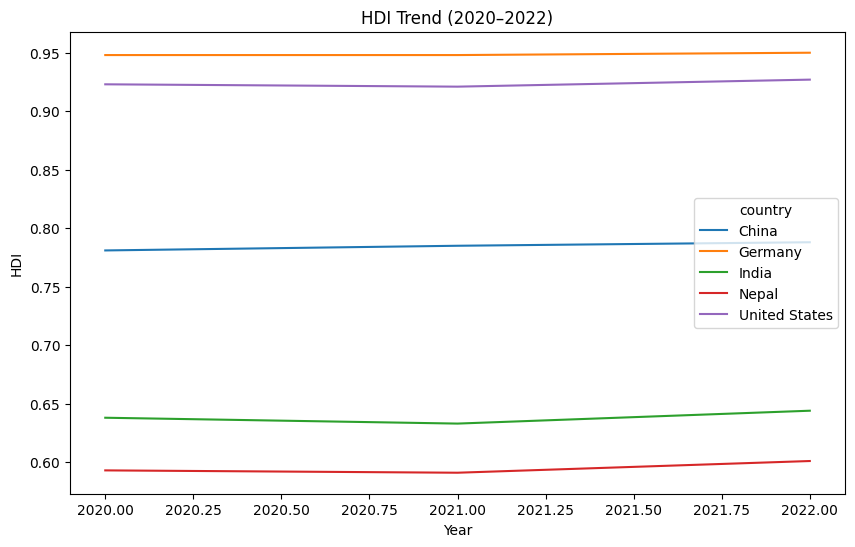

In [49]:
#Task 3A: Line Chart (5 Countries)
import matplotlib.pyplot as plt
import seaborn as sns

target_df = hdi_2020_22

countries = ['Nepal', 'India', 'China', 'United States', 'Germany']
line_df = target_df[target_df['country'].isin(countries)]

plt.figure(figsize=(10, 6))
sns.lineplot(data=line_df, x='year', y='hdi', hue='country')
plt.title("HDI Trend (2020–2022)")
plt.xlabel("Year")
plt.ylabel("HDI")
plt.show()


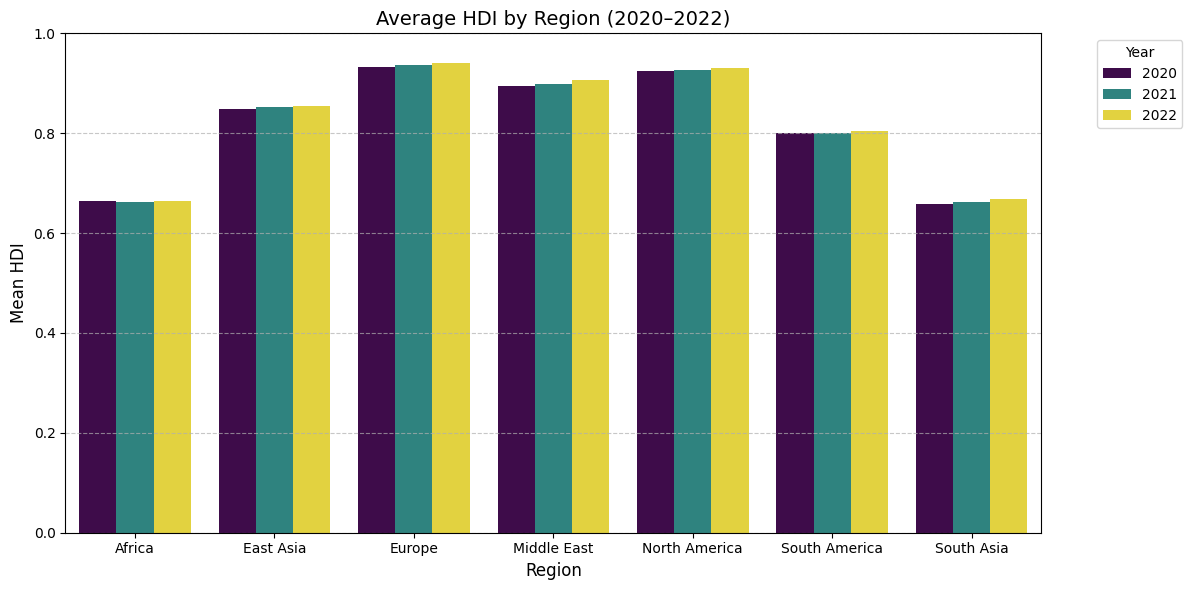

In [55]:
# Task 3B: Bar Chart – Average HDI by Region
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


hdi_1b_df = hdi_2020_22.copy()

# 1. Create a Dictionary to Map Countries to Regions
region_mapping = {
    'India': 'South Asia', 'Pakistan': 'South Asia', 'Bangladesh': 'South Asia',
    'Sri Lanka': 'South Asia', 'Nepal': 'South Asia', 'Bhutan': 'South Asia', 'Maldives': 'South Asia',
    'China': 'East Asia', 'Japan': 'East Asia', 'South Korea': 'East Asia',
    'United States': 'North America', 'Canada': 'North America',
    'Germany': 'Europe', 'France': 'Europe', 'United Kingdom': 'Europe', 'Norway': 'Europe',
    'Brazil': 'South America', 'Argentina': 'South America',
    'Nigeria': 'Africa', 'South Africa': 'Africa', 'Egypt': 'Africa',
    'Saudi Arabia': 'Middle East', 'United Arab Emirates': 'Middle East'
}

# 2. Apply the Mapping
hdi_1b_df['Region'] = hdi_1b_df['country'].map(region_mapping)

# 3. Filter: Keep only the rows where a Region was successfully assigned
region_subset = hdi_1b_df.dropna(subset=['Region']).copy()


region_subset['hdi'] = pd.to_numeric(region_subset['hdi'], errors='coerce')
region_avg = region_subset.groupby(['Region', 'year'])['hdi'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=region_avg, x="Region", y="hdi", hue="year", palette="viridis")

plt.title("Average HDI by Region (2020–2022)", fontsize=14)
plt.xlabel("Region", fontsize=12)
plt.ylabel("Mean HDI", fontsize=12)
plt.ylim(0, 1.0)
plt.legend(title="Year", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

In [51]:
#Task 3B: Bar Chart – Average HDI by Region
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_path = '/content/Human_Development_Index_Dataset (1).csv'
df = pd.read_csv(file_path, encoding='latin1')

hdi_1b_df = df[df['year'].isin([2020, 2021, 2022])].copy()

hdi_1b_df.columns = hdi_1b_df.columns.str.strip().str.lower()

print("All systems go! Data is loaded and cleaned.")
hdi_1b_df.head()

All systems go! Data is loaded and cleaned.


,unnamed: 0,iso3,country,year,hdi,life_expectancy,pop_millions,hdi_f,hdi_m,life_expec_f,...,gender_development,gender_inequality,secondary_education_f_%,secondary_education_m_%,seats_in_parliament_f_%,seats_in_parliament_m_%,labour_participation_f_%,labour_participation_m_%,co2_emission_tons,mat_footprint_percap_tons
30,31,AFG,Afghanistan,2020,0.488,62.575,38.972231,0.381373,0.548741,65.432,...,0.695,0.674,6.092345,15.945160,27.215190,72.784810,16.50,66.84,0.305040,1.5554
31,32,AFG,Afghanistan,2021,0.473,61.982,40.099462,0.379129,0.528559,65.279,...,0.717,0.653,6.395730,14.865710,27.215190,72.784810,23.33,77.09,0.306318,1.2351
32,33,AFG,Afghanistan,2022,0.462,62.879,41.128771,0.332443,0.534145,66.213,...,0.622,0.665,7.042050,24.077040,27.215190,72.784810,23.33,77.09,0.306318,1.1809
63,64,ALB,Albania,2020,0.784,76.989,2.866849,0.775404,0.793220,79.676,...,0.978,0.129,82.249185,86.476634,29.508197,70.491803,54.45,68.91,1.750668,10.4704
64,65,ALB,Albania,2021,0.785,76.463,2.854710,0.777866,0.792942,79.173,...,0.981,0.117,82.249185,86.476634,35.714286,64.285714,56.08,69.91,1.717758,11.5865


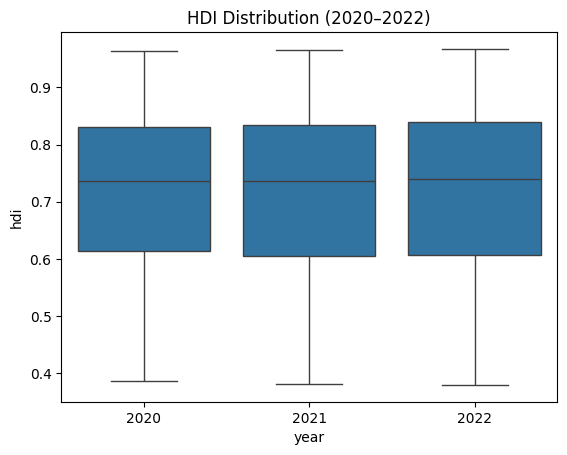

In [ ]:
plt.figure()
sns.boxplot(data=hdi_1b_df, x='year', y='hdi')
plt.title("HDI Distribution (2020–2022)")
plt.show()


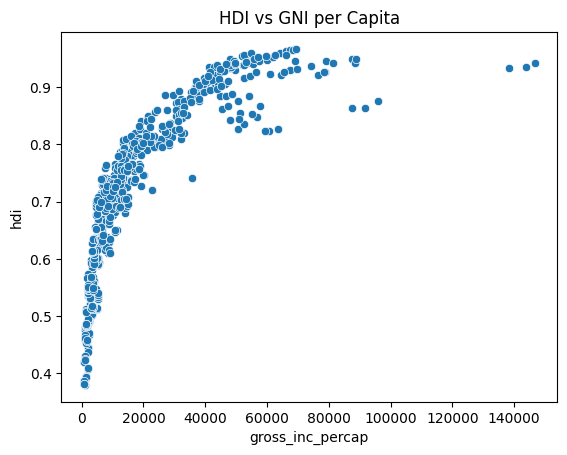

In [ ]:
plt.figure()
sns.scatterplot(data=hdi_1b_df, x='gross_inc_percap', y='hdi')
plt.title("HDI vs GNI per Capita")
plt.show()

In [41]:
#4 Short Analysis Questions:
#a.Which countries show the greatest improvement in HDI from 2020 to 2022?
df_hdi_change = hdi_2020_22[hdi_2020_22['year'].isin([2020, 2022])]
hdi_pivot = df_hdi_change.pivot(index='country', columns='year', values='hdi')
hdi_pivot.columns = ['HDI_2020', 'HDI_2022']
hdi_pivot = hdi_pivot.dropna()
hdi_pivot['HDI_change'] = hdi_pivot['HDI_2022'] - hdi_pivot['HDI_2020']
top_improved = hdi_pivot.sort_values(by='HDI_change', ascending=False).head(10)
top_improved

,HDI_2020,HDI_2022,HDI_change
country,,,
Azerbaijan,0.722,0.760,0.038
Ecuador,0.734,0.765,0.031
Maldives,0.737,0.762,0.025
Mexico,0.757,0.781,0.024
Tajikistan,0.656,0.679,0.023
San Marino,0.844,0.867,0.023
Bahamas,0.798,0.820,0.022
Kuwait,0.826,0.847,0.021
Türkiye,0.835,0.855,0.020


In [57]:
#b Did any countries experience a decline in HDI? Provide possible reasons.
decline_hdi = hdi_pivot[hdi_pivot['HDI_change'] < 0]
decline_hdi_sorted = decline_hdi.sort_values(by='HDI_change')
decline_hdi_sorted

,HDI_2020,HDI_2022,HDI_change
country,,,
Timor-Leste,0.633,0.566,-0.067
Ukraine,0.762,0.734,-0.028
Afghanistan,0.488,0.462,-0.026
Namibia,0.634,0.610,-0.024
Lebanon,0.742,0.723,-0.019
Suriname,0.702,0.690,-0.012
Eswatini (Kingdom Of),0.622,0.610,-0.012
Gabon,0.704,0.693,-0.011
Paraguay,0.742,0.731,-0.011


In [59]:

avg_hdi_region = region_subset.groupby('Region')['hdi'].mean().sort_values(ascending=False)

print("Average HDI by Region (Highest to Lowest):")
print(avg_hdi_region)
highest_region = avg_hdi_region.idxmax()
lowest_region = avg_hdi_region.idxmin()

print(f"\nThe region with the highest average HDI is: {highest_region}")
print(f"The region with the lowest average HDI is: {lowest_region}")

Average HDI by Region (Highest to Lowest):
Region
Europe           0.937167
North America    0.928000
Middle East      0.900167
East Asia        0.851833
South America    0.801333
Africa           0.663556
South Asia       0.663190
Name: hdi, dtype: float64

The region with the highest average HDI is: Europe
The region with the lowest average HDI is: South Asia


In [ ]:
print("=" * 90)
print("PROBLEM 2 – ADVANCED HDI (SOUTH ASIA)")
print("=" * 90)

PROBLEM 2 – ADVANCED HDI (SOUTH ASIA)


In [60]:
#Task 1: South Asia Subset
import pandas as pd

file_path = '/content/Human_Development_Index_Dataset (1).csv'
df = pd.read_csv(file_path, encoding='latin1')

south_asia = ["Afghanistan", "Bangladesh", "Bhutan", "India",
              "Maldives", "Nepal", "Pakistan", "Sri Lanka"]

south_df = df[df['country'].isin(south_asia)].copy()

south_df.to_csv("/content/HDI_SouthAsia.csv", index=False)

print("Success! 'south_df' created and saved as HDI_SouthAsia.csv")
south_df.head()

Success! 'south_df' created and saved as HDI_SouthAsia.csv


,Unnamed: 0,iso3,country,year,hdi,life_expectancy,pop_millions,hdi_f,hdi_m,life_expec_f,...,gender_development,gender_inequality,secondary_education_f_%,secondary_education_m_%,seats_in_parliament_f_%,seats_in_parliament_m_%,labour_participation_f_%,labour_participation_m_%,co2_emission_tons,mat_footprint_percap_tons
0,1,AFG,Afghanistan,1990,0.284,45.967,10.694796,NaN,NaN,48.397,...,NaN,NaN,1.107733,7.899011,NaN,NaN,NaN,NaN,0.189279,2.1809
1,2,AFG,Afghanistan,1991,0.292,46.663,10.745167,NaN,NaN,49.144,...,NaN,NaN,1.221396,8.137953,NaN,NaN,NaN,NaN,0.178155,2.5264
2,3,AFG,Afghanistan,1992,0.299,47.596,12.057433,NaN,NaN,50.320,...,NaN,NaN,1.335059,8.376896,NaN,NaN,NaN,NaN,0.122920,2.6421
3,4,AFG,Afghanistan,1993,0.307,51.466,14.003760,NaN,NaN,52.739,...,NaN,NaN,1.448722,8.615838,NaN,NaN,NaN,NaN,0.106179,2.3022
4,5,AFG,Afghanistan,1994,0.300,51.495,15.455554,NaN,NaN,53.544,...,NaN,NaN,1.562385,8.854780,NaN,NaN,NaN,NaN,0.094063,1.8948


In [61]:

south_asia_countries = ["Afghanistan", "Bangladesh", "Bhutan", "India", "Maldives", "Nepal", "Pakistan", "Sri Lanka"]
hdi_south_asia = df[df['country'].isin(south_asia_countries)].copy()
hdi_south_asia.to_csv("HDI_SouthAsia.csv", index = False)
hdi_south_asia['country'].unique()

array(['Afghanistan', 'Bangladesh', 'Bhutan', 'India', 'Maldives',
       'Nepal', 'Pakistan', 'Sri Lanka'], dtype=object)

In [64]:
south_df.columns


Index(['Unnamed: 0', 'iso3', 'country', 'year', 'hdi', 'life_expectancy',
       'pop_millions', 'hdi_f', 'hdi_m', 'life_expec_f', 'life_expec_m',
       'expec_yr_school', 'expec_yr_school_f', 'expec_yr_school_m',
       'mean_yr_school', 'mean_yr_school_f', 'mean_yr_school_m',
       'gross_inc_percap', 'gross_inc_percap_f', 'gross_inc_percap_m',
       'gender_development', 'gender_inequality', 'secondary_education_f_%',
       'secondary_education_m_%', 'seats_in_parliament_f_%',
       'seats_in_parliament_m_%', 'labour_participation_f_%',
       'labour_participation_m_%', 'co2_emission_tons',
       'mat_footprint_percap_tons'],
      dtype='object')

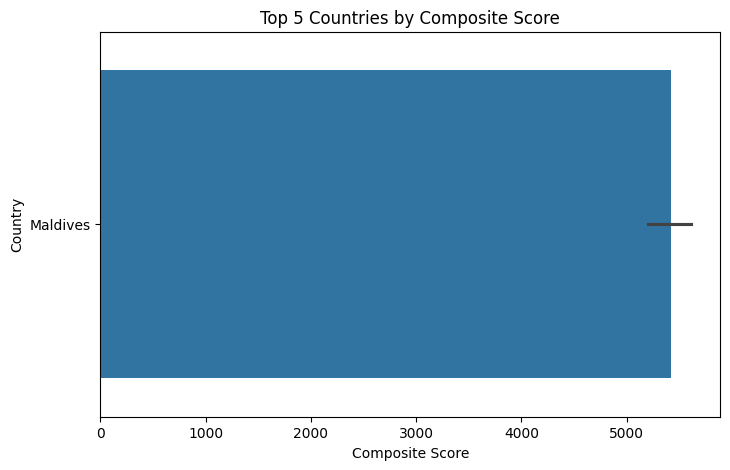

In [65]:

# Task 2: Composite Score
south_df['composite_score'] = (
    0.30 * south_df['life_expectancy'] +
    0.30 * south_df['gross_inc_percap']
)

# Sort by composite score
ranked = south_df.sort_values(by='composite_score', ascending=False)

# Display top 5
ranked.head()

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(
    data=ranked.head(5),
    x='composite_score',
    y='country',
    orient='h'
)
plt.xlabel('Composite Score')
plt.ylabel('Country')
plt.title('Top 5 Countries by Composite Score')
plt.show()



In [66]:
#Task 2: Composite Development Score
hdi_south_asia = hdi_south_asia.copy()
le_max = hdi_south_asia['life_expectancy'].max()
le_min = hdi_south_asia['life_expectancy'].min()
hdi_south_asia.loc[:, 'life_exp_index'] = (hdi_south_asia['life_expectancy'] - le_min) / (le_max - le_min)
gni_min = hdi_south_asia['gross_inc_percap'].min()
gni_max = hdi_south_asia['gross_inc_percap'].max()
hdi_south_asia.loc[:, 'gni_index'] = (hdi_south_asia['gross_inc_percap'] - gni_min)/ (gni_max - gni_min)

hdi_south_asia.loc[:, 'composite_score'] = (0.30 * hdi_south_asia['life_exp_index'] + 0.30 * hdi_south_asia['gni_index'])
south_asia_2022 = hdi_south_asia[hdi_south_asia['year'] == 2022]
composite_ranking = south_asia_2022.sort_values(by = 'composite_score', ascending = False)
composite_ranking[['country', 'composite_score']]

,country,composite_score
3530,Maldives,0.600000
5477,Sri Lanka,0.446959
659,Bhutan,0.387867
461,Bangladesh,0.331426
2573,India,0.287583
4091,Nepal,0.262039
4388,Pakistan,0.249819
32,Afghanistan,0.151438


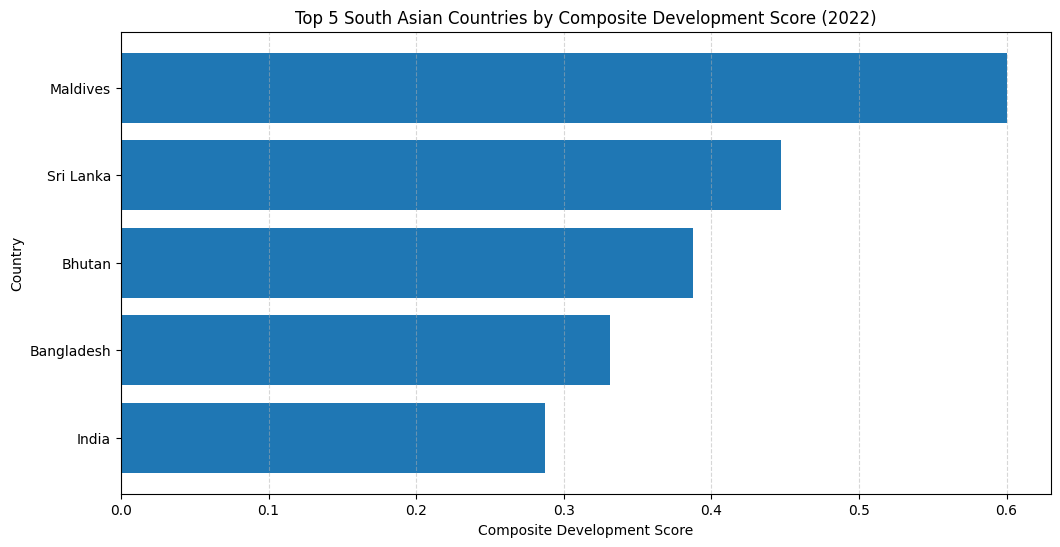

In [67]:
top5 = composite_ranking.head(5)

plt.figure(figsize = (12,6))
plt.barh(top5['country'], top5['composite_score'])
plt.xlabel("Composite Development Score")
plt.ylabel('Country')
plt.title('Top 5 South Asian Countries by Composite Development Score (2022)')
plt.gca().invert_yaxis()
plt.grid(axis = 'x', linestyle = '--', alpha = 0.5)
plt.show()

In [68]:
comparison = south_asia_2022.sort_values(by='hdi', ascending=False)[['country', 'hdi', 'composite_score']]
print(comparison)

          country    hdi  composite_score
5477    Sri Lanka  0.780         0.446959
3530     Maldives  0.762         0.600000
659        Bhutan  0.681         0.387867
461    Bangladesh  0.670         0.331426
2573        India  0.644         0.287583
4091        Nepal  0.601         0.262039
4388     Pakistan  0.540         0.249819
32    Afghanistan  0.462         0.151438


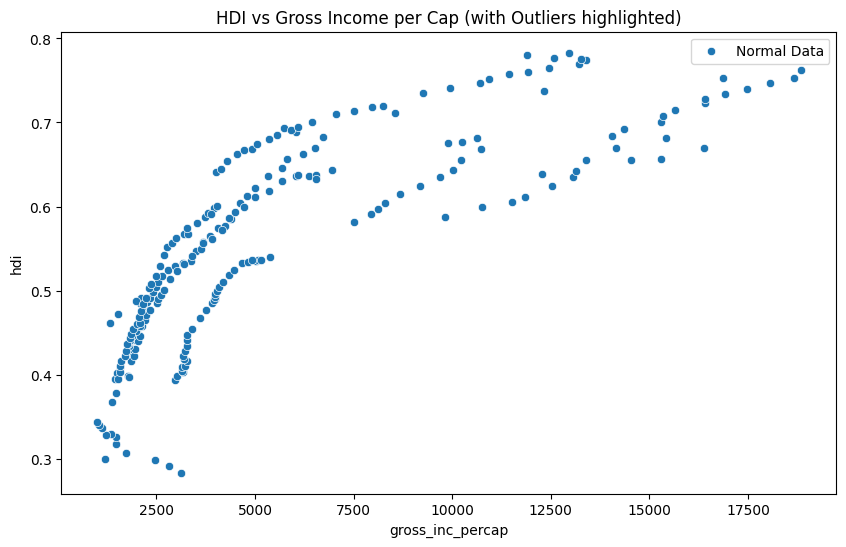

In [ ]:
#Task 3: Outlier Detection (IQR)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

south_df.columns = south_df.columns.str.replace(' ', '_').str.lower()

Q1 = south_df['hdi'].quantile(0.25)
Q3 = south_df['hdi'].quantile(0.75)
IQR = Q3 - Q1

outliers = south_df[(south_df['hdi'] < Q1 - 1.5 * IQR) |
                    (south_df['hdi'] > Q3 + 1.5 * IQR)]

plt.figure(figsize=(10, 6))

sns.scatterplot(data=south_df, x='gross_inc_percap', y='hdi', label='Normal Data')

sns.scatterplot(data=outliers, x='gross_inc_percap', y='hdi', color='red', label='Outliers')

plt.title('HDI vs Gross Income per Cap (with Outliers highlighted)')
plt.legend()
plt.show()

                         hdi  life_expectancy  gender_development
hdi                 1.000000         0.958761            0.865621
life_expectancy     0.958761         1.000000            0.829553
gender_development  0.865621         0.829553            1.000000


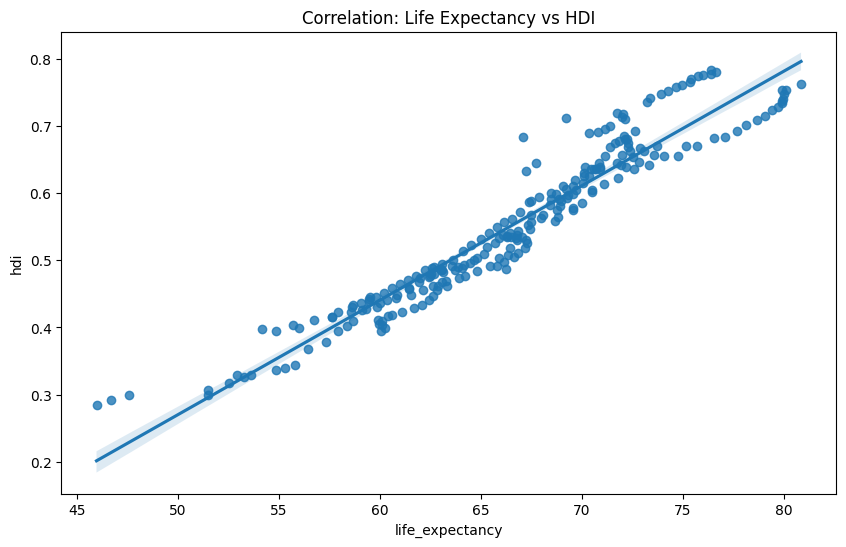

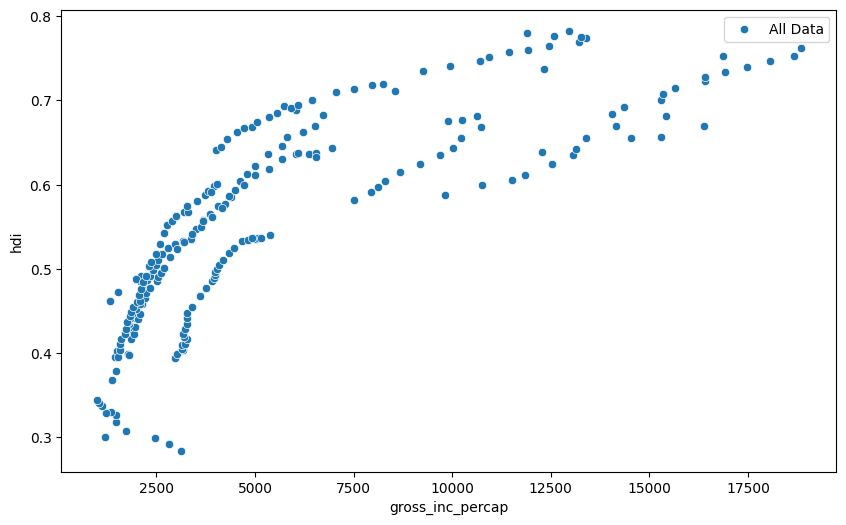

In [ ]:
#Task 4: Correlation

south_df.columns = south_df.columns.str.strip().str.lower().str.replace(' ', '_')

print(south_df[['hdi', 'life_expectancy', 'gender_development']].corr())

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.regplot(data=south_df, x='life_expectancy', y='hdi')
plt.title('Correlation: Life Expectancy vs HDI')
plt.show()

plt.figure(figsize=(10,6))
sns.scatterplot(data=south_df, x='gross_inc_percap', y='hdi', label='All Data')
plt.show()

                         hdi  life_expectancy  gender_development
hdi                 1.000000         0.958761            0.865621
life_expectancy     0.958761         1.000000            0.829553
gender_development  0.865621         0.829553            1.000000


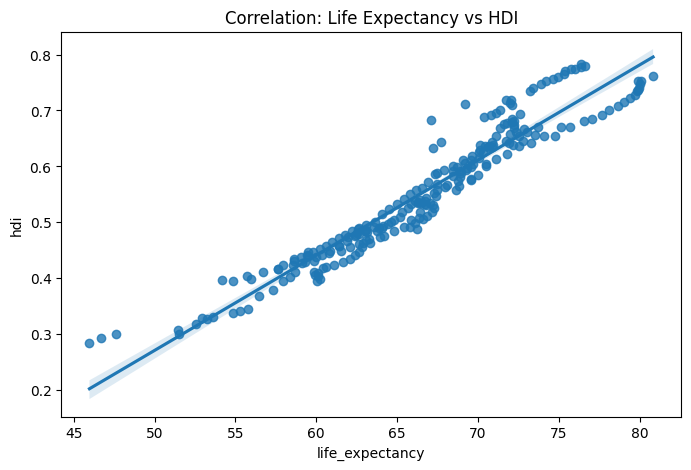

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = ['hdi', 'life_expectancy', 'gender_development']
print(south_df[cols].corr())

plt.figure(figsize=(8, 5))
sns.regplot(data=south_df, x='life_expectancy', y='hdi')
plt.title('Correlation: Life Expectancy vs HDI')
plt.show()

In [ ]:
#Task 5: GNI–HDI Gap

south_df.columns = south_df.columns.str.strip().str.lower().str.replace(' ', '_')

print("Your corrected column names are:")
print(south_df.columns.tolist())

Your corrected column names are:
['unnamed:_0', 'iso3', 'country', 'year', 'hdi', 'life_expectancy', 'pop_millions', 'hdi_f', 'hdi_m', 'life_expec_f', 'life_expec_m', 'expec_yr_school', 'expec_yr_school_f', 'expec_yr_school_m', 'mean_yr_school', 'mean_yr_school_f', 'mean_yr_school_m', 'gross_inc_percap', 'gross_inc_percap_f', 'gross_inc_percap_m', 'gender_development', 'gender_inequality', 'secondary_education_f_%', 'secondary_education_m_%', 'seats_in_parliament_f_%', 'seats_in_parliament_m_%', 'labour_participation_f_%', 'labour_participation_m_%', 'co2_emission_tons', 'mat_footprint_percap_tons', 'composite_score']


Top 3 GNI-HDI Gap:
      unnamed:_0 iso3   country  year    hdi  life_expectancy  pop_millions  \
3530        3531  MDV  Maldives  2022  0.762           80.839      0.523787   
3527        3528  MDV  Maldives  2019  0.753           80.116      0.504508   
3526        3527  MDV  Maldives  2018  0.747           80.013      0.489758   

         hdi_f     hdi_m  life_expec_f  ...  secondary_education_f_%  \
3530  0.748233  0.767001        81.844  ...                46.928068   
3527  0.753833  0.752974        81.162  ...                45.125182   
3526  0.727985  0.754359        81.074  ...                43.322295   

      secondary_education_m_%  seats_in_parliament_f_%  \
3530                46.269366                 4.597701   
3527                44.598528                 4.597701   
3526                42.927689                 5.882353   

      seats_in_parliament_m_%  labour_participation_f_%  \
3530                95.402299                     53.34   
3527                95.4

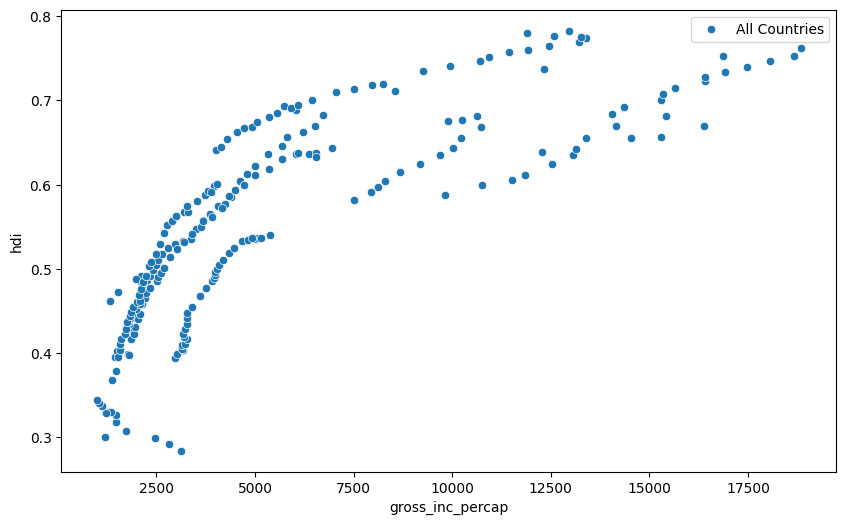

In [ ]:
south_df['gni_hdi_gap'] = south_df['gross_inc_percap'] - south_df['hdi']

print("Top 3 GNI-HDI Gap:")
print(south_df.sort_values(by='gni_hdi_gap', ascending=False).head(3))

plt.figure(figsize=(10, 6))
sns.scatterplot(data=south_df, x='gross_inc_percap', y='hdi', label='All Countries')

if 'outliers' in locals():
    outliers.columns = outliers.columns.str.strip().str.lower().str.replace(' ', '_')
    sns.scatterplot(data=outliers, x='gross_inc_percap', y='hdi', color='red', label='Outliers')

plt.legend()
plt.show()

In [69]:
# Task 5. Gap Analysis:
hdi_south_asia_2022 = hdi_south_asia[hdi_south_asia['year'] == 2022]
hdi_south_asia_2022 = hdi_south_asia_2022[['country', 'gross_inc_percap', 'hdi']].dropna()
hdi_south_asia_2022['gni_hdi_gap'] = hdi_south_asia_2022['gross_inc_percap'] - hdi_south_asia_2022['hdi']
gap_desc = hdi_south_asia_2022.sort_values(by='gni_hdi_gap', ascending=False)
gap_desc


,country,gross_inc_percap,hdi,gni_hdi_gap
3530,Maldives,18846.792190,0.762,18846.030190
5477,Sri Lanka,11899.498470,0.780,11898.718470
659,Bhutan,10624.873880,0.681,10624.192880
2573,India,6950.526798,0.644,6949.882798
461,Bangladesh,6511.122178,0.670,6510.452178
4388,Pakistan,5374.270423,0.540,5373.730423
4091,Nepal,4025.554685,0.601,4024.953685
32,Afghanistan,1335.205733,0.462,1334.743733


In [70]:
gap_asc = hdi_south_asia_2022.sort_values(by='gni_hdi_gap', ascending=True)
gap_asc

,country,gross_inc_percap,hdi,gni_hdi_gap
32,Afghanistan,1335.205733,0.462,1334.743733
4091,Nepal,4025.554685,0.601,4024.953685
4388,Pakistan,5374.270423,0.540,5373.730423
461,Bangladesh,6511.122178,0.670,6510.452178
2573,India,6950.526798,0.644,6949.882798
659,Bhutan,10624.873880,0.681,10624.192880
5477,Sri Lanka,11899.498470,0.780,11898.718470
3530,Maldives,18846.792190,0.762,18846.030190


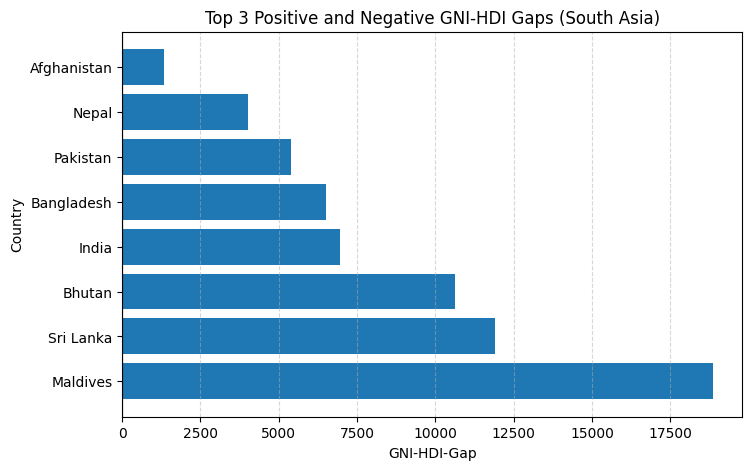

In [71]:
top_positive = gap_desc.head(10)
top_negative = gap_asc.head(10)

plot_data = pd.concat([top_positive, top_negative])

plt.figure(figsize=(8,5))
plt.barh(plot_data['country'], plot_data['gni_hdi_gap'])
plt.axvline(0, color='black', linewidth=0.8)

plt.xlabel('GNI-HDI-Gap')
plt.ylabel('Country')
plt.title('Top 3 Positive and Negative GNI-HDI Gaps (South Asia)')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()


In [ ]:
print("=" * 120)
print("PROBLEM 3 – SOUTH ASIA vs MIDDLE EAST")
print("=" * 120)

PROBLEM 3 – SOUTH ASIA vs MIDDLE EAST


In [72]:
#Task 1: Create South Asia and Middle East subsets (2020–2022)
import pandas as pd


df = pd.read_csv("HDI_problem1B.csv")


south_asia_countries = [
    "Afghanistan", "Bangladesh", "Bhutan",
    "India", "Maldives", "Nepal",
    "Pakistan", "Sri Lanka"
]

middle_east_countries = [
    "Bahrain", "Iran", "Iraq", "Israel", "Jordan",
    "Kuwait", "Lebanon", "Oman", "Palestine", "Qatar",
    "Saudi Arabia", "Syria", "United Arab Emirates", "Yemen"
]


south_asia_df = df[df["country"].isin(south_asia_countries)]
middle_east_df = df[df["country"].isin(middle_east_countries)]


south_asia_df.to_csv("HDI_SouthAsia_2020_2022.csv", index=False)
middle_east_df.to_csv("HDI_MiddleEast_2020_2022.csv", index=False)


print("South Asia rows:", south_asia_df.shape[0])
print("Middle East rows:", middle_east_df.shape[0])


South Asia rows: 24
Middle East rows: 33


In [73]:
#Task 2: Descriptive Statistics (HDI: 2020–2022)
import pandas as pd

south_df = pd.read_csv("HDI_SouthAsia_2020_2022.csv")
middle_df = pd.read_csv("HDI_MiddleEast_2020_2022.csv")

In [74]:
#Compute mean and standard deviation of HDI
south_stats = south_df["hdi"].agg(["mean", "std"])
middle_stats = middle_df["hdi"].agg(["mean", "std"])

print("South Asia HDI Statistics:")
print(south_stats)

print("\nMiddle East HDI Statistics:")
print(middle_stats)

South Asia HDI Statistics:
mean    0.639583
std     0.098273
Name: hdi, dtype: float64

Middle East HDI Statistics:
mean    0.788909
std     0.141295
Name: hdi, dtype: float64


In [75]:

#Task3 Top and Bottom Performers by HDI (2020–2022)
import pandas as pd
import matplotlib.pyplot as plt

south_df = pd.read_csv("HDI_SouthAsia_2020_2022.csv")
middle_df = pd.read_csv("HDI_MiddleEast_2020_2022.csv")

In [76]:
#Compute average HDI per country (2020–2022)
south_avg = south_df.groupby("country")["hdi"].mean().sort_values(ascending=False)
middle_avg = middle_df.groupby("country")["hdi"].mean().sort_values(ascending=False)

In [77]:
#Identify top 3 and bottom 3 countries
# South Asia
south_top3 = south_avg.head(3)
south_bottom3 = south_avg.tail(3)

# Middle East
middle_top3 = middle_avg.head(3)
middle_bottom3 = middle_avg.tail(3)

print("South Asia – Top 3:\n", south_top3)
print("\nSouth Asia – Bottom 3:\n", south_bottom3)

print("\nMiddle East – Top 3:\n", middle_top3)
print("\nMiddle East – Bottom 3:\n", middle_bottom3)

South Asia – Top 3:
 country
Sri Lanka    0.780000
Maldives     0.750667
Bhutan       0.677667
Name: hdi, dtype: float64

South Asia – Bottom 3:
 country
Nepal          0.595000
Pakistan       0.537667
Afghanistan    0.474333
Name: hdi, dtype: float64

Middle East – Top 3:
 country
United Arab Emirates    0.932667
Israel                  0.910667
Bahrain                 0.885333
Name: hdi, dtype: float64

Middle East – Bottom 3:
 country
Lebanon    0.730000
Iraq       0.667000
Yemen      0.426333
Name: hdi, dtype: float64


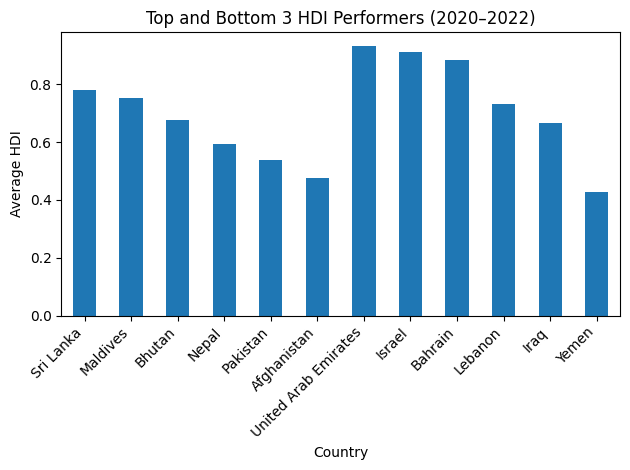

In [78]:
#Bar chart comparison (top & bottom performers)
# Combine for plotting
plot_df = pd.concat([
    south_top3,
    south_bottom3,
    middle_top3,
    middle_bottom3
])

plt.figure()
plot_df.plot(kind="bar")
plt.title("Top and Bottom 3 HDI Performers (2020–2022)")
plt.ylabel("Average HDI")
plt.xlabel("Country")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [79]:
#Task 4 Metric Comparisons
import pandas as pd
import matplotlib.pyplot as plt

# Load datasets
south_df = pd.read_csv("HDI_SouthAsia_2020_2022.csv")
middle_df = pd.read_csv("HDI_MiddleEast_2020_2022.csv")

In [80]:
metrics = ["gender_development", "life_expectancy", "gross_inc_percap"]

# Average per country
south_avg = south_df.groupby("country")[metrics].mean()
middle_avg = middle_df.groupby("country")[metrics].mean()

In [81]:
#Prepare data for grouped bar chart
# Regional average
south_region_avg = south_avg.mean().rename("South Asia")
middle_region_avg = middle_avg.mean().rename("Middle East")

# Combine into one DataFrame
comparison_df = pd.concat([south_region_avg, middle_region_avg], axis=1)
comparison_df

,South Asia,Middle East
gender_development,0.881458,0.896545
life_expectancy,70.970083,75.855455
gross_inc_percap,7766.509931,37750.770520


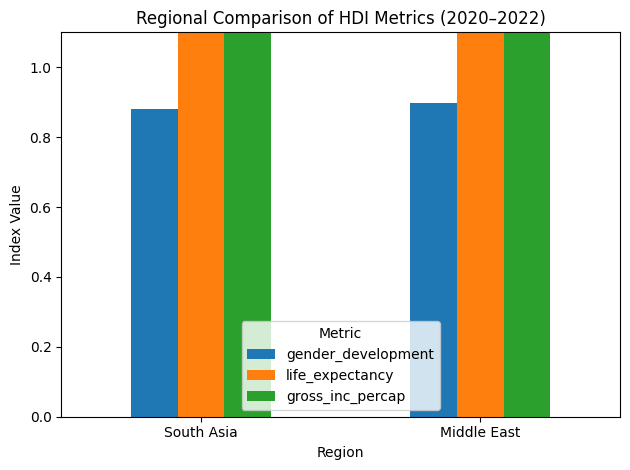

In [82]:
#Plot grouped bar chart
# Plot
comparison_df.T.plot(kind="bar")
plt.title("Regional Comparison of HDI Metrics (2020–2022)")
plt.ylabel("Index Value")
plt.xlabel("Region")
plt.xticks(rotation=0)
plt.ylim(0, 1.1)  # Index scale
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

In [83]:
#Task 5 HDI Disparity:
import pandas as pd

south_df = pd.read_csv("HDI_SouthAsia_2020_2022.csv")
middle_df = pd.read_csv("HDI_MiddleEast_2020_2022.csv")



In [84]:
#Compute HDI range (max − min)
# South Asia
south_range = south_df['hdi'].max() - south_df['hdi'].min()

# Middle East
middle_range = middle_df['hdi'].max() - middle_df['hdi'].min()

print(f"South Asia HDI Range: {south_range:.3f}")
print(f"Middle East HDI Range: {middle_range:.3f}")

South Asia HDI Range: 0.321
Middle East HDI Range: 0.513


In [85]:
#Compute Coefficient of Variation (CV = std/mean)
# South Asia
south_cv = south_df['hdi'].std() / south_df['hdi'].mean()

# Middle East
middle_cv = middle_df['hdi'].std() / middle_df['hdi'].mean()

print(f"South Asia HDI CV: {south_cv:.3f}")
print(f"Middle East HDI CV: {middle_cv:.3f}")

South Asia HDI CV: 0.154
Middle East HDI CV: 0.179


In [86]:
#Task 6 Correlation Analysis
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
south_df = pd.read_csv("HDI_SouthAsia_2020_2022.csv")
middle_df = pd.read_csv("HDI_MiddleEast_2020_2022.csv")

In [87]:
#Compute correlations
metrics = ["gender_development", "life_expectancy"]

# South Asia correlations
south_corr = south_df[["hdi"] + metrics].corr()["hdi"].drop("hdi")
print("South Asia correlations:\n", south_corr)

# Middle East correlations
middle_corr = middle_df[["hdi"] + metrics].corr()["hdi"].drop("hdi")
print("\nMiddle East correlations:\n", middle_corr)

South Asia correlations:
 gender_development    0.874218
life_expectancy       0.938764
Name: hdi, dtype: float64

Middle East correlations:
 gender_development    0.935670
life_expectancy       0.933123
Name: hdi, dtype: float64


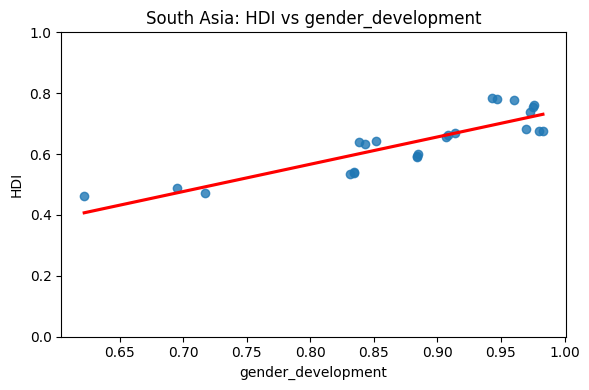

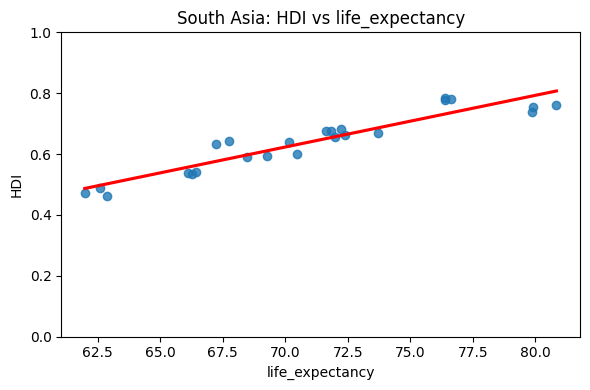

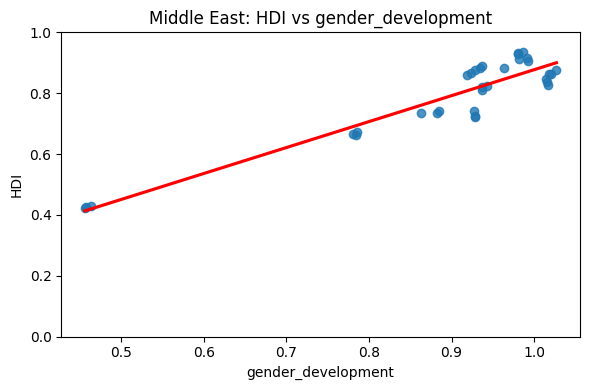

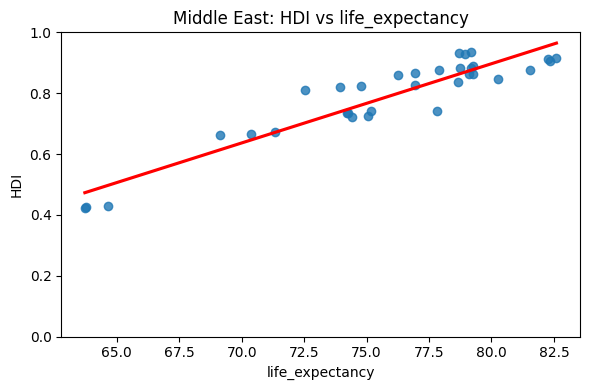

In [88]:
#Scatter plots with trendlines
# Define function to plot scatter with trendline
def scatter_with_trend(df, x_col, y_col, region):
    plt.figure(figsize=(6,4))
    sns.regplot(x=x_col, y=y_col, data=df, ci=None, line_kws={"color":"red"})
    plt.title(f"{region}: HDI vs {x_col}")
    plt.xlabel(x_col)
    plt.ylabel("HDI")
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

# South Asia
for metric in metrics:
    scatter_with_trend(south_df, metric, "hdi", "South Asia")

# Middle East
for metric in metrics:
    scatter_with_trend(middle_df, metric, "hdi", "Middle East")

In [89]:
# Task 7
import pandas as pd
import matplotlib.pyplot as plt

south_df = pd.read_csv("HDI_SouthAsia_2020_2022.csv")
middle_df = pd.read_csv("HDI_MiddleEast_2020_2022.csv")


In [90]:

def detect_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    return outliers


In [91]:
# HDI outliers
south_hdi_out = detect_outliers(south_df, "hdi")
middle_hdi_out = detect_outliers(middle_df, "hdi")

# GNI per Capita outliers
south_gni_out = detect_outliers(south_df, "gross_inc_percap")
middle_gni_out = detect_outliers(middle_df, "gross_inc_percap")

print("South Asia HDI Outliers:\n", south_hdi_out[["country", "hdi"]])
print("\nMiddle East HDI Outliers:\n", middle_hdi_out[["country", "hdi"]])

print("\nSouth Asia GNI Outliers:\n", south_gni_out[["country", "gross_inc_percap"]])
print("\nMiddle East GNI Outliers:\n", middle_gni_out[["country", "gross_inc_percap"]])

South Asia HDI Outliers:
 Empty DataFrame
Columns: [country, hdi]
Index: []

Middle East HDI Outliers:
    country    hdi
30   Yemen  0.430
31   Yemen  0.425
32   Yemen  0.424

South Asia GNI Outliers:
 Empty DataFrame
Columns: [country, gross_inc_percap]
Index: []

Middle East GNI Outliers:
 Empty DataFrame
Columns: [country, gross_inc_percap]
Index: []


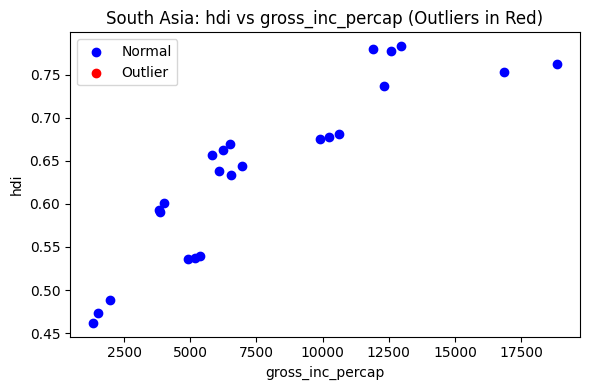

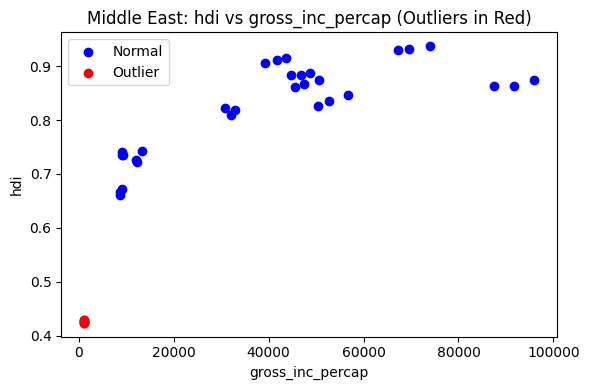

In [92]:
def scatter_outliers(df, x_col, y_col, region):
    outliers = detect_outliers(df, y_col)

    plt.figure(figsize=(6,4))
    plt.scatter(df[x_col], df[y_col], color='blue', label='Normal')
    plt.scatter(outliers[x_col], outliers[y_col], color='red', label='Outlier')
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(f"{region}: {y_col} vs {x_col} (Outliers in Red)")
    plt.legend()
    plt.tight_layout()
    plt.show()

# HDI vs GNI for South Asia
scatter_outliers(south_df, "gross_inc_percap", "hdi", "South Asia")

# HDI vs GNI for Middle East
scatter_outliers(middle_df, "gross_inc_percap", "hdi", "Middle East")